In [210]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# Dataset

In [211]:
df = pd.read_csv('https://raw.githubusercontent.com/eduardofc/data/main/boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [212]:
df.dtypes
df.shape

(506, 13)

# Plots

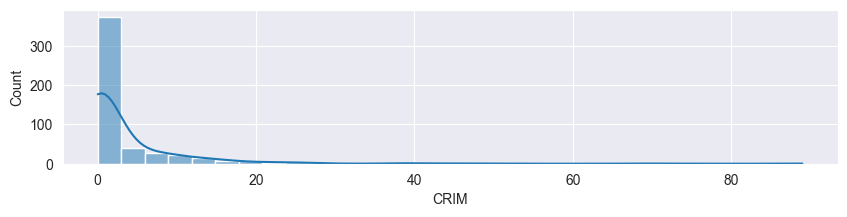

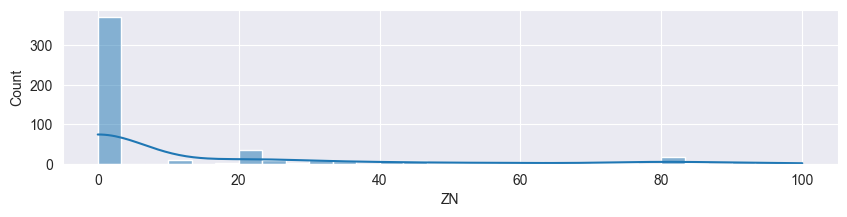

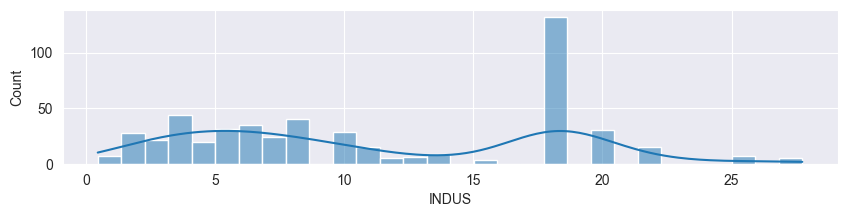

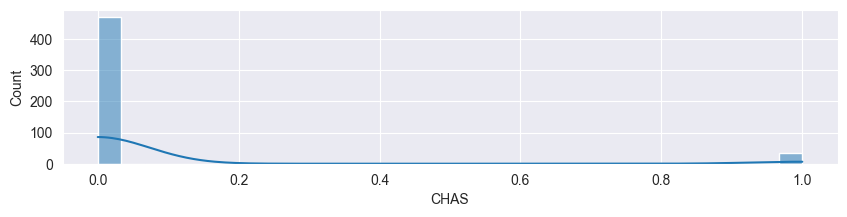

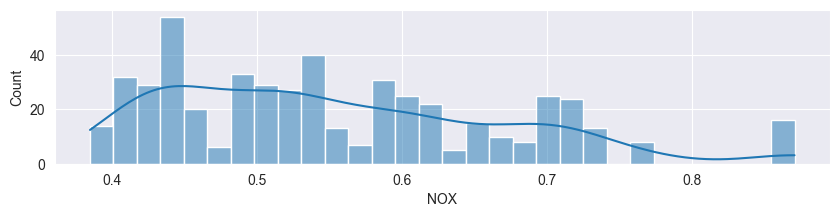

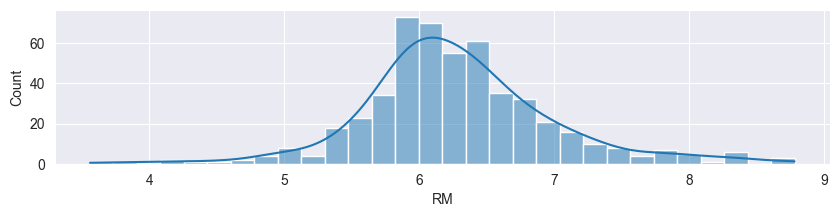

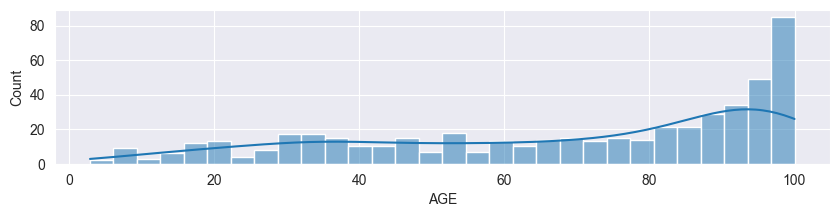

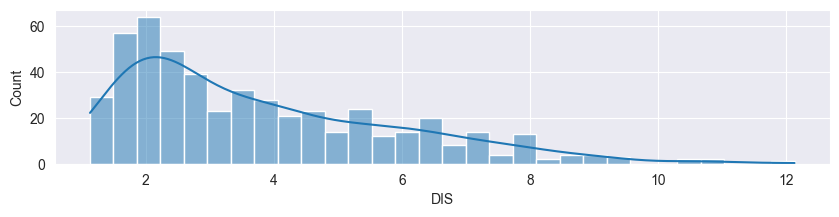

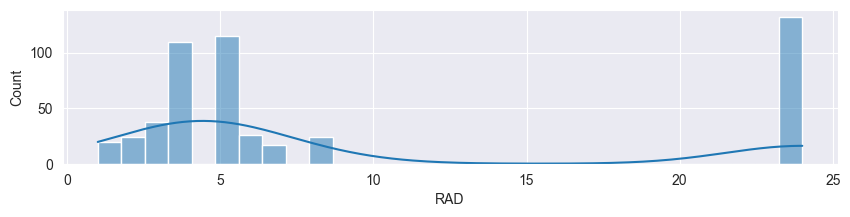

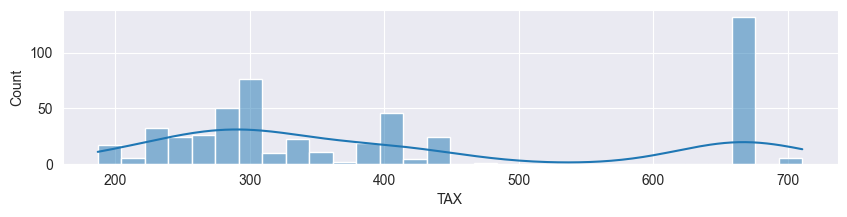

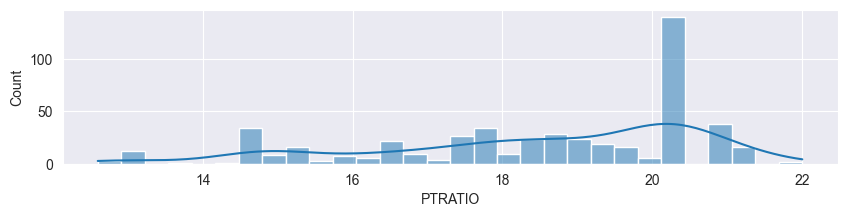

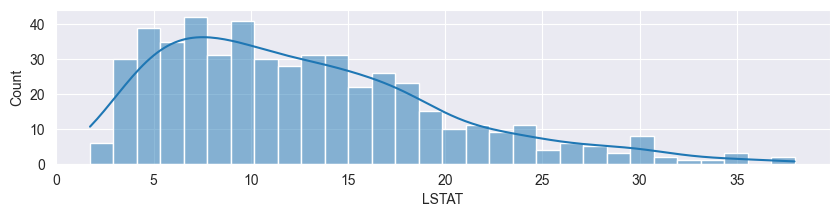

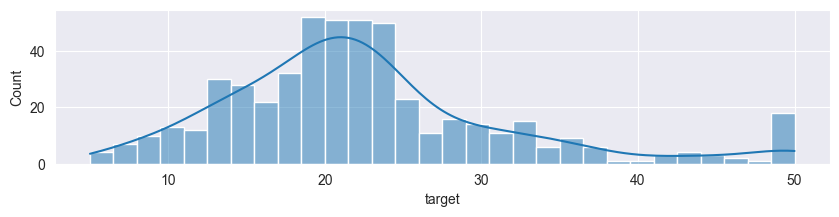

In [213]:
""" variables unidimenisonales """

for col in df.columns:
    plt.figure(figsize=(10,2))
    # sns.histplot(data=df, x=col)
    # sns.histplot(data=df, x=col, bins=30)
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.show()

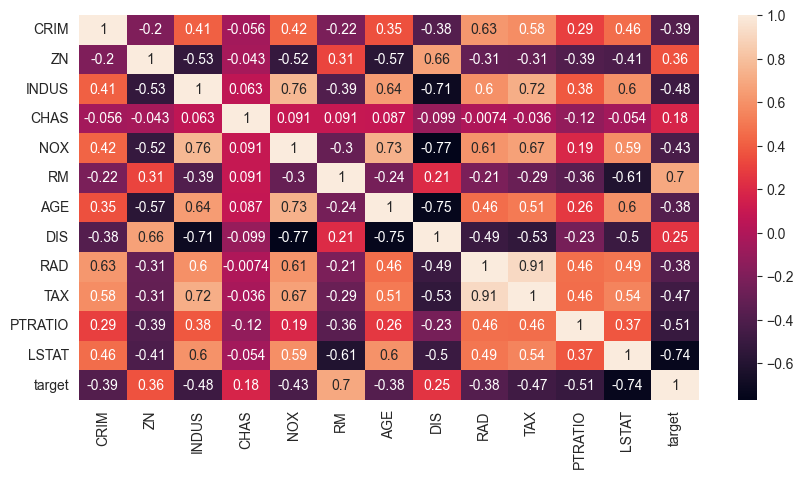

In [214]:
""" bidimensionales"""

df.corr(numeric_only=True)

plt.figure(figsize=(10,5))
sns.heatmap(data=df.corr(numeric_only=True), annot=True)
plt.show()

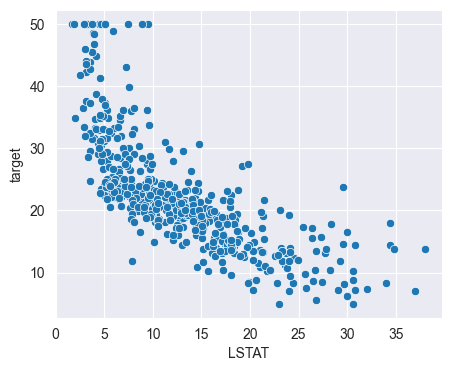

In [215]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x='LSTAT', y='target')
plt.show()

In [216]:
# sns.pairplot(df)
# plt.show()

# Librería sklearn

In [217]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [218]:
# Regresión simple

y = df['target']
X = df[['LSTAT']]

model = LinearRegression()
model.fit(X, y)
y_hat = model.predict(X)

r2_score(y_true=y, y_pred=y_hat)

# ojo a la relacion entre correlacion y r2
# 0.74**2 = 0.544

0.5441462975864797

In [219]:
# Regresión múltiple

y = df['target']
X = df.drop(columns='target')

model = LinearRegression()
model.fit(X, y)
y_hat = model.predict(X)

r2_score(y_true=y, y_pred=y_hat)

0.7343070437613075

# Transformación de features

In [220]:
# Standard scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X1 = scaler.fit_transform(X)
X1

array([[-0.41978194,  0.28482986, -1.2879095 , ..., -0.66660821,
        -1.45900038, -1.0755623 ],
       [-0.41733926, -0.48772236, -0.59338101, ..., -0.98732948,
        -0.30309415, -0.49243937],
       [-0.41734159, -0.48772236, -0.59338101, ..., -0.98732948,
        -0.30309415, -1.2087274 ],
       ...,
       [-0.41344658, -0.48772236,  0.11573841, ..., -0.80321172,
         1.17646583, -0.98304761],
       [-0.40776407, -0.48772236,  0.11573841, ..., -0.80321172,
         1.17646583, -0.86530163],
       [-0.41500016, -0.48772236,  0.11573841, ..., -0.80321172,
         1.17646583, -0.66905833]])

In [221]:
# MinMax scaler

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X2 = scaler.fit_transform(X)
X2

array([[0.00000000e+00, 1.80000000e-01, 6.78152493e-02, ...,
        2.08015267e-01, 2.87234043e-01, 8.96799117e-02],
       [2.35922539e-04, 0.00000000e+00, 2.42302053e-01, ...,
        1.04961832e-01, 5.53191489e-01, 2.04470199e-01],
       [2.35697744e-04, 0.00000000e+00, 2.42302053e-01, ...,
        1.04961832e-01, 5.53191489e-01, 6.34657837e-02],
       ...,
       [6.11892474e-04, 0.00000000e+00, 4.20454545e-01, ...,
        1.64122137e-01, 8.93617021e-01, 1.07891832e-01],
       [1.16072990e-03, 0.00000000e+00, 4.20454545e-01, ...,
        1.64122137e-01, 8.93617021e-01, 1.31070640e-01],
       [4.61841693e-04, 0.00000000e+00, 4.20454545e-01, ...,
        1.64122137e-01, 8.93617021e-01, 1.69701987e-01]])

In [222]:
# Robust Scaler

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X3 = scaler.fit_transform(X)
X3

array([[-0.06959315,  1.44      , -0.57164988, ..., -0.0878553 ,
        -1.33928571, -0.63768116],
       [-0.06375455,  0.        , -0.20294345, ..., -0.22739018,
        -0.44642857, -0.22188906],
       [-0.06376011,  0.        , -0.20294345, ..., -0.22739018,
        -0.44642857, -0.73263368],
       ...,
       [-0.05445006,  0.        ,  0.17350891, ..., -0.14728682,
         0.69642857, -0.57171414],
       [-0.04086745,  0.        ,  0.17350891, ..., -0.14728682,
         0.69642857, -0.48775612],
       [-0.05816351,  0.        ,  0.17350891, ..., -0.14728682,
         0.69642857, -0.34782609]])

In [223]:
# Polinomiales

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X4 = poly.fit_transform(X)
X4

array([[6.32000e-03, 1.80000e+01, 2.31000e+00, ..., 2.34090e+02,
        7.61940e+01, 2.48004e+01],
       [2.73100e-02, 0.00000e+00, 7.07000e+00, ..., 3.16840e+02,
        1.62692e+02, 8.35396e+01],
       [2.72900e-02, 0.00000e+00, 7.07000e+00, ..., 3.16840e+02,
        7.17340e+01, 1.62409e+01],
       ...,
       [6.07600e-02, 0.00000e+00, 1.19300e+01, ..., 4.41000e+02,
        1.18440e+02, 3.18096e+01],
       [1.09590e-01, 0.00000e+00, 1.19300e+01, ..., 4.41000e+02,
        1.36080e+02, 4.19904e+01],
       [4.74100e-02, 0.00000e+00, 1.19300e+01, ..., 4.41000e+02,
        1.65480e+02, 6.20944e+01]])

In [224]:
# plt.figure(figsize=(10,5))
# sns.heatmap(data=pd.DataFrame(X4).corr(numeric_only=True), annot=True)
# plt.show()

In [225]:
# Power Transformer

from sklearn.preprocessing import PowerTransformer

poly = PowerTransformer()
X5 = poly.fit_transform(X)
X5

array([[-1.05615089,  1.60526992, -1.52377643, ..., -0.55633375,
        -1.40887389, -1.25709923],
       [-0.99990077, -0.59995411, -0.44393776, ..., -1.17588739,
        -0.51869194, -0.33442163],
       [-0.9999533 , -0.59995411, -0.44393776, ..., -1.17588739,
        -0.51869194, -1.54345266],
       ...,
       [-0.91475707, -0.59995411,  0.29306121, ..., -0.79731533,
         1.43070472, -1.08007767],
       [-0.79947765, -0.59995411,  0.29306121, ..., -0.79731533,
         1.43070472, -0.87516238],
       [-0.94810109, -0.59995411,  0.29306121, ..., -0.79731533,
         1.43070472, -0.57335234]])

In [226]:
for features in [X, X1, X2, X3, X4, X5]:

    model = LinearRegression()
    model.fit(features, y)
    y_hat = model.predict(features)

    r2 = r2_score(y_true=y, y_pred=y_hat)
    print(r2)

0.7343070437613075
0.7343070437613076
0.7343070437613076
0.7343070437613076
0.9213737830057598
0.7718701697782138


# Train/Test split

In [227]:
from sklearn.model_selection import train_test_split

y = df['target']
X = df.drop(columns='target')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(404, 12)
(102, 12)
(404,)
(102,)


In [228]:
model = LinearRegression()
model.fit(X_train, y_train)
y_hat = model.predict(X_test)

r2_score(y_true=y_test, y_pred=y_hat)

0.6893967884614781

# Overfitting

In [229]:
model = LinearRegression()
model.fit(X_train, y_train)

y_hat_train = model.predict(X_train)
y_hat_test = model.predict(X_test)

r2_train = r2_score(y_true=y_train, y_pred=y_hat_train)
r2_test = r2_score(y_true=y_test, y_pred=y_hat_test)

print(r2_train,r2_test)

0.739801993681731 0.6893967884614781


# Cross-Validation

In [230]:
from sklearn.model_selection import cross_val_score, KFold

model = LinearRegression()

cv_results = cross_val_score(model, X, y, cv=KFold(n_splits=10, shuffle=True, random_state=42), scoring='r2')
cv_results

array([0.7756276 , 0.62797071, 0.74784772, 0.7060658 , 0.61748023,
       0.792152  , 0.75661591, 0.78246472, 0.72747374, 0.5905608 ])

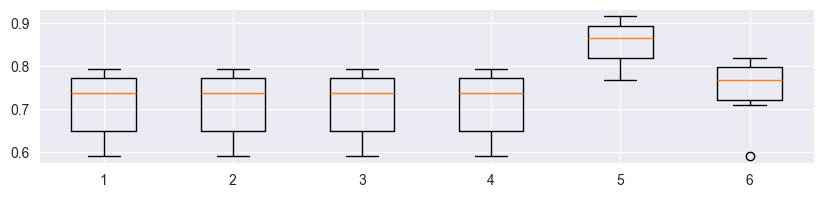

In [231]:
results = []

for features in [X, X1, X2, X3, X4, X5]:

    model = LinearRegression()
    cv_results = cross_val_score(model, features, y, cv=KFold(n_splits=10, shuffle=True, random_state=42), scoring='r2')

    results.append(cv_results)

plt.figure(figsize=(10,2))
plt.boxplot(results)
plt.show()

# Librería OLS

In [232]:
import statsmodels.api as sm

In [233]:
# Regresión simple

X = df[['LSTAT']]
y = df['target']

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 target   R-squared (uncentered):                   0.449
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                              410.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):                    2.71e-67
Time:                        17:15:57   Log-Likelihood:                         -2182.4
No. Observations:                 506   AIC:                                      4367.
Df Residuals:                     505   BIC:                                      4371.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
LSTAT          1.1221      0.055     20.271      0.000       1.013       1.231
==============================================================================
Omnibus:                        1.113   Durbin-Watson:                   0.369
Prob(Omnibus):                  0.573   Jarque-Bera (JB):                1.051
Skew:                           0.112   Prob(JB):                        0.591
Kurtosis:                       3.009   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [234]:
# Regresión simple, y las constantes

y = df['target']
X = df[['LSTAT']]
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           5.08e-88
Time:                        17:15:57   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.5538      0.563     61.415      0.000      33.448      35.659
LSTAT         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [251]:
# Regresión múltiple

y = df['target']
X = df.drop(columns='target')
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          2.23e-133
Time:                        17:21:15   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.6173      4.936      8.431      0.000      31.919      51.316
CRIM          -0.1214      0.033     -3.678      0.000      -0.186      -0.057
ZN             0.0470      0.014      3.384      0.001       0.020       0.074
INDUS          0.0135      0.062      0.217      0.829      -0.109       0.136
CHAS           2.8400      0.870      3.264      0.001       1.131       4.549
NOX          -18.7580      3.851     -4.870      0.000     -26.325     -11.191
RM             3.6581      0.420      8.705      0.000       2.832       4.484
AGE            0.0036      0.013      0.271      0.787      -0.023       0.030
DIS           -1.4908      0.202     -7.394      0.000      -1.887      -1.095
RAD            0.2894      0.067      4.325      0.000       0.158       0.421
TAX           -0.0127      0.004     -3.337      0.001      -0.020      -0.005
PTRATIO       -0.9375      0.132     -7.091      0.000      -1.197      -0.678
LSTAT         -0.5520      0.051    -10.897      0.000      -0.652      -0.452
==============================================================================
Omnibus:                      171.096   Durbin-Watson:                   1.077
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              709.937
Skew:                           1.477   Prob(JB):                    6.90e-155
Kurtosis:                       7.995   Cond. No.                     1.17e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.17e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Análisis de los residuos

In [252]:
y_hat = model.predict(X)
r2_score(y_true=y, y_pred=y_hat)

0.7343070437613076

In [255]:
residuos = model.resid
residuos = y - y_hat

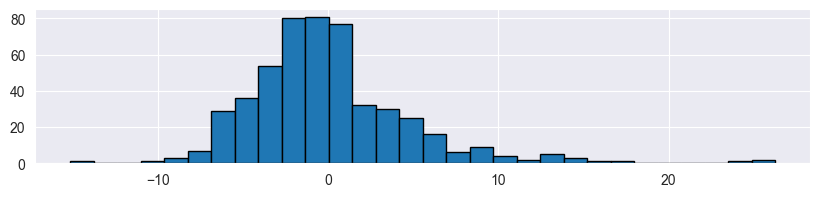

In [256]:
plt.figure(figsize=(10,2))
plt.hist(model.resid, bins=30, edgecolor='black')
plt.show()

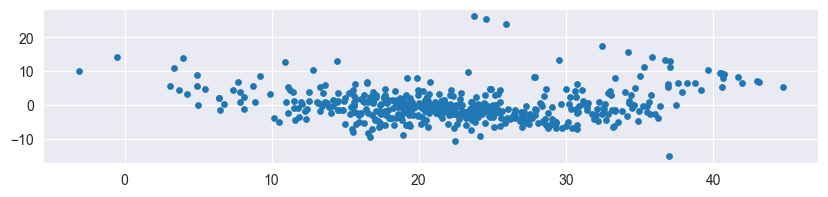

In [262]:
plt.figure(figsize=(10,2))
plt.scatter(y_hat, residuos, s=15)
plt.show()

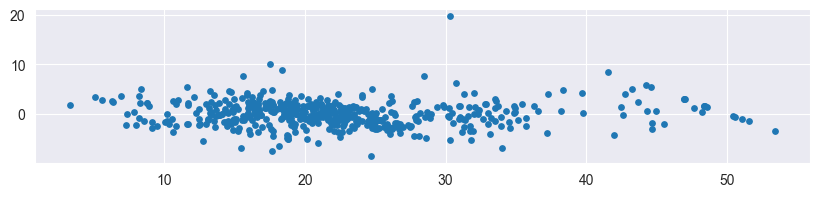

In [268]:
# EJERCICIO, plotear los residuos con X4

X4_const = sm.add_constant(X4)

model = OLS(y, X4_const).fit()

y_hat = model.predict(X4_const)
residuos = model.resid

plt.figure(figsize=(10,2))
plt.scatter(y_hat, residuos, s=15)
plt.show()

# Eliminación de variables

In [237]:
## FIV

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [238]:
X = df.drop(columns='target')
X = sm.add_constant(X)

for ii, col in enumerate(X.columns):
    vif = variance_inflation_factor(X.values, ii)
    print(f"{col}: {vif:.2f}")

const: 535.53
CRIM: 1.77
ZN: 2.30
INDUS: 3.99
CHAS: 1.07
NOX: 4.37
RM: 1.91
AGE: 3.09
DIS: 3.95
RAD: 7.45
TAX: 9.00
PTRATIO: 1.80
LSTAT: 2.87


In [239]:
df1 = df.drop(columns=['TAX'])

X = df1.drop(columns='target')
X = sm.add_constant(X)

for ii, col in enumerate(X.columns):
    vif = variance_inflation_factor(X.values, ii)
    print(f"{col}: {vif:.2f}")

const: 529.48
CRIM: 1.77
ZN: 2.18
INDUS: 3.22
CHAS: 1.06
NOX: 4.34
RM: 1.90
AGE: 3.09
DIS: 3.95
RAD: 2.77
PTRATIO: 1.79
LSTAT: 2.87


In [240]:
y = df1['target']
X = df1.drop(columns='target')
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     120.4
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          4.68e-132
Time:                        17:15:57   Log-Likelihood:                -1510.6
No. Observations:                 506   AIC:                             3045.
Df Residuals:                     494   BIC:                             3096.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.8673      4.958      8.041      0.000      30.126      49.609
CRIM          -0.1204      0.033     -3.612      0.000      -0.186      -0.055
ZN             0.0366      0.014      2.681      0.008       0.010       0.063
INDUS         -0.0776      0.056     -1.376      0.169      -0.188       0.033
CHAS           3.1964      0.872      3.665      0.000       1.483       4.910
NOX          -19.7453      3.879     -5.090      0.000     -27.367     -12.124
RM             3.7590      0.423      8.877      0.000       2.927       4.591
AGE            0.0024      0.013      0.175      0.861      -0.024       0.029
DIS           -1.5043      0.204     -7.387      0.000      -1.904      -1.104
RAD            0.1125      0.041      2.729      0.007       0.032       0.194
PTRATIO       -0.9705      0.133     -7.287      0.000      -1.232      -0.709
LSTAT         -0.5501      0.051    -10.750      0.000      -0.651      -0.450
==============================================================================
Omnibus:                      161.497   Durbin-Watson:                   1.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              632.122
Skew:                           1.407   Prob(JB):                    5.45e-138
Kurtosis:                       7.697   Cond. No.                     2.08e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.08e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [241]:
df2 = df1.drop(columns=['AGE'])

X = df2.drop(columns='target')
X = sm.add_constant(X)

for ii, col in enumerate(X.columns):
    vif = variance_inflation_factor(X.values, ii)
    print(f"{col}: {vif:.2f}")

const: 527.15
CRIM: 1.77
ZN: 2.15
INDUS: 3.22
CHAS: 1.05
NOX: 4.04
RM: 1.83
DIS: 3.61
RAD: 2.75
PTRATIO: 1.77
LSTAT: 2.55


In [242]:
y = df2['target']
X = df2.drop(columns='target')
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     132.7
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          4.02e-133
Time:                        17:15:57   Log-Likelihood:                -1510.6
No. Observations:                 506   AIC:                             3043.
Df Residuals:                     495   BIC:                             3090.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.8099      4.942      8.055      0.000      30.099      49.521
CRIM          -0.1204      0.033     -3.617      0.000      -0.186      -0.055
ZN             0.0364      0.014      2.681      0.008       0.010       0.063
INDUS         -0.0775      0.056     -1.375      0.170      -0.188       0.033
CHAS           3.2042      0.870      3.682      0.000       1.494       4.914
NOX          -19.5660      3.737     -5.236      0.000     -26.909     -12.223
RM             3.7738      0.414      9.105      0.000       2.959       4.588
DIS           -1.5147      0.195     -7.787      0.000      -1.897      -1.133
RAD            0.1119      0.041      2.727      0.007       0.031       0.192
PTRATIO       -0.9685      0.133     -7.304      0.000      -1.229      -0.708
LSTAT         -0.5471      0.048    -11.362      0.000      -0.642      -0.452
==============================================================================
Omnibus:                      162.407   Durbin-Watson:                   1.086
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              640.919
Skew:                           1.413   Prob(JB):                    6.70e-140
Kurtosis:                       7.735   Cond. No.                         820.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [243]:
df3 = df2.drop(columns=['INDUS'])

X = df3.drop(columns='target')
X = sm.add_constant(X)

for ii, col in enumerate(X.columns):
    vif = variance_inflation_factor(X.values, ii)
    print(f"{col}: {vif:.2f}")

const: 526.81
CRIM: 1.76
ZN: 2.15
CHAS: 1.05
NOX: 3.54
RM: 1.79
DIS: 3.41
RAD: 2.70
PTRATIO: 1.72
LSTAT: 2.52


In [244]:
y = df3['target']
X = df3.drop(columns='target')
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     146.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          8.23e-134
Time:                        17:15:57   Log-Likelihood:                -1511.5
No. Observations:                 506   AIC:                             3043.
Df Residuals:                     496   BIC:                             3085.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9841      4.945      8.085      0.000      30.268      49.700
CRIM          -0.1185      0.033     -3.559      0.000      -0.184      -0.053
ZN             0.0366      0.014      2.695      0.007       0.010       0.063
CHAS           3.1394      0.870      3.610      0.000       1.431       4.848
NOX          -21.3757      3.501     -6.106      0.000     -28.254     -14.497
RM             3.8506      0.411      9.368      0.000       3.043       4.658
DIS           -1.4508      0.189     -7.674      0.000      -1.822      -1.079
RAD            0.1046      0.041      2.569      0.010       0.025       0.185
PTRATIO       -1.0018      0.130     -7.677      0.000      -1.258      -0.745
LSTAT         -0.5535      0.048    -11.537      0.000      -0.648      -0.459
==============================================================================
Omnibus:                      160.486   Durbin-Watson:                   1.085
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              623.744
Skew:                           1.400   Prob(JB):                    3.59e-136
Kurtosis:                       7.663   Cond. No.                         774.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [245]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df4 = scaler.fit_transform(df3)
df4 = pd.DataFrame(df4, columns=scaler.get_feature_names_out())
df4.head()

,CRIM,ZN,CHAS,NOX,RM,DIS,RAD,PTRATIO,LSTAT,target
0,-0.419782,0.284830,-0.272599,-0.144217,0.413672,0.140214,-0.982843,-1.459000,-1.075562,0.159686
1,-0.417339,-0.487722,-0.272599,-0.740262,0.194274,0.557160,-0.867883,-0.303094,-0.492439,-0.101524
2,-0.417342,-0.487722,-0.272599,-0.740262,1.282714,0.557160,-0.867883,-0.303094,-1.208727,1.324247
3,-0.416750,-0.487722,-0.272599,-0.835284,1.016303,1.077737,-0.752922,0.113032,-1.361517,1.182758
4,-0.412482,-0.487722,-0.272599,-0.835284,1.228577,1.077737,-0.752922,0.113032,-1.026501,1.487503


In [246]:
# ganamos explicabilidad

y = df4['target']
X = df4.drop(columns='target')
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     146.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          8.23e-134
Time:                        17:15:58   Log-Likelihood:                -389.28
No. Observations:                 506   AIC:                             798.6
Df Residuals:                     496   BIC:                             840.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.235e-16      0.023  -2.23e-14      1.000      -0.046       0.046
CRIM          -0.1109      0.031     -3.559      0.000      -0.172      -0.050
ZN             0.0928      0.034      2.695      0.007       0.025       0.160
CHAS           0.0867      0.024      3.610      0.000       0.040       0.134
NOX           -0.2693      0.044     -6.106      0.000      -0.356      -0.183
RM             0.2942      0.031      9.368      0.000       0.232       0.356
DIS           -0.3322      0.043     -7.674      0.000      -0.417      -0.247
RAD            0.0990      0.039      2.569      0.010       0.023       0.175
PTRATIO       -0.2358      0.031     -7.677      0.000      -0.296      -0.175
LSTAT         -0.4297      0.037    -11.537      0.000      -0.503      -0.357
==============================================================================
Omnibus:                      160.486   Durbin-Watson:                   1.085
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              623.744
Skew:                           1.400   Prob(JB):                    3.59e-136
Kurtosis:                       7.663   Cond. No.                         4.88
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""